# Clustering - Kümeleme

CLustering Benzer nesnelerin veya verilerin gruplar halinde toplanması demektir. Bu projede Arabaları benzerliklerine göre gruplara ayıracağız.

In [3]:
import pandas as pd

In [4]:
import warnings 
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df=pd.read_excel('cars.xls')

In [85]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
338,12495.970751,26204,Chevrolet,Cobalt,Sedan 4D,Sedan,4,2.2,4,0,1,1


Hatirlatma
Regression icin r2_score ve RMSE
Classification in Accuracy, precision, recall f1-score 
Clustering silhouette score 

In [88]:
x=df[['Price','Mileage','Cylinder','Make']]

In [96]:
x=pd.get_dummies(x)

In [98]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [100]:
model=KMeans(4)

In [102]:
model=model.fit(x)

In [104]:
tahmin=model.predict(x)

In [107]:
x['cluster']=tahmin

In [ ]:
x.sample(10)

In [ ]:
sns.countplot(x=x['cluster'])

In [16]:
silhouette_score(x, tahmin)

0.4099937931025646

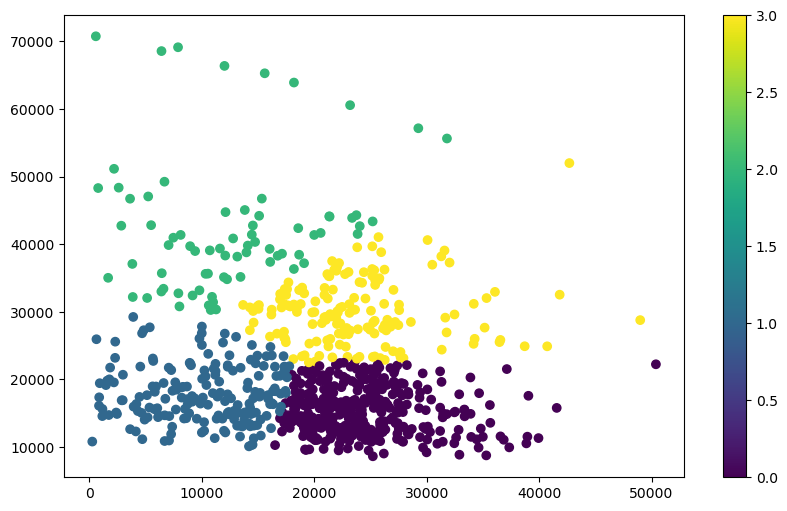

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(x.Mileage,x.Price, c=tahmin)
plt.colorbar();

In [18]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.4510408939884079
0.4033924760034631
0.41226018819785454
0.3537653699330861
0.3618796838167798
0.35321910265929657
0.3282599521448204
0.3452400671261881


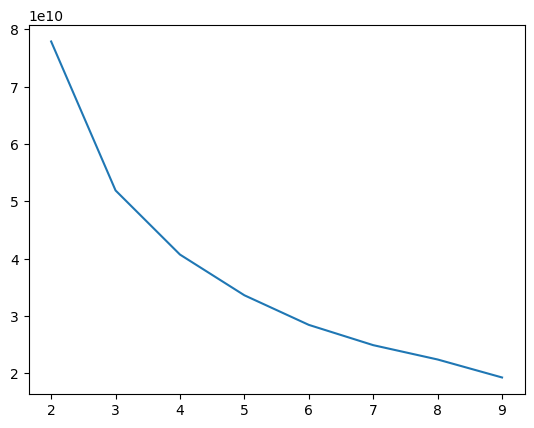

In [19]:
plt.plot(range(2,10),wcss) # dirsek nerede kirilirsa optimim grup o kadardir/

In [20]:
from yellowbrick.cluster import KElbowVisualizer

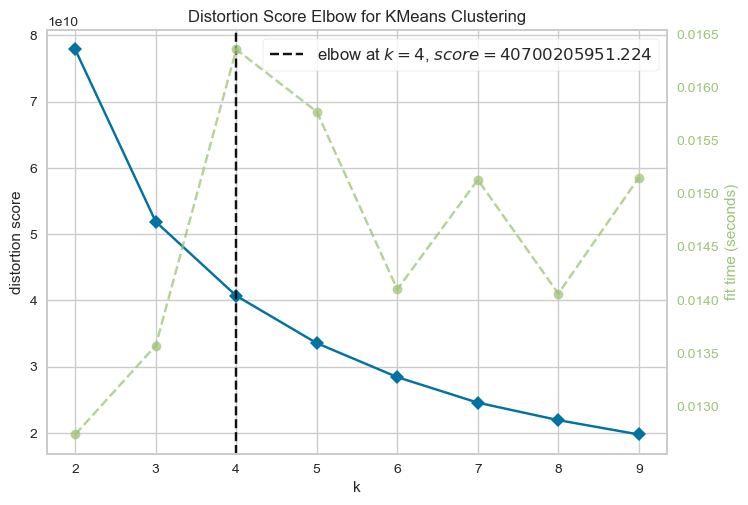

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
vis=KElbowVisualizer(KMeans(),k=(2,10))
vis.fit(x)
vis.show()

# Hierarchical clustering

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [24]:
data=linkage(x,method='ward',metric='euclidean')

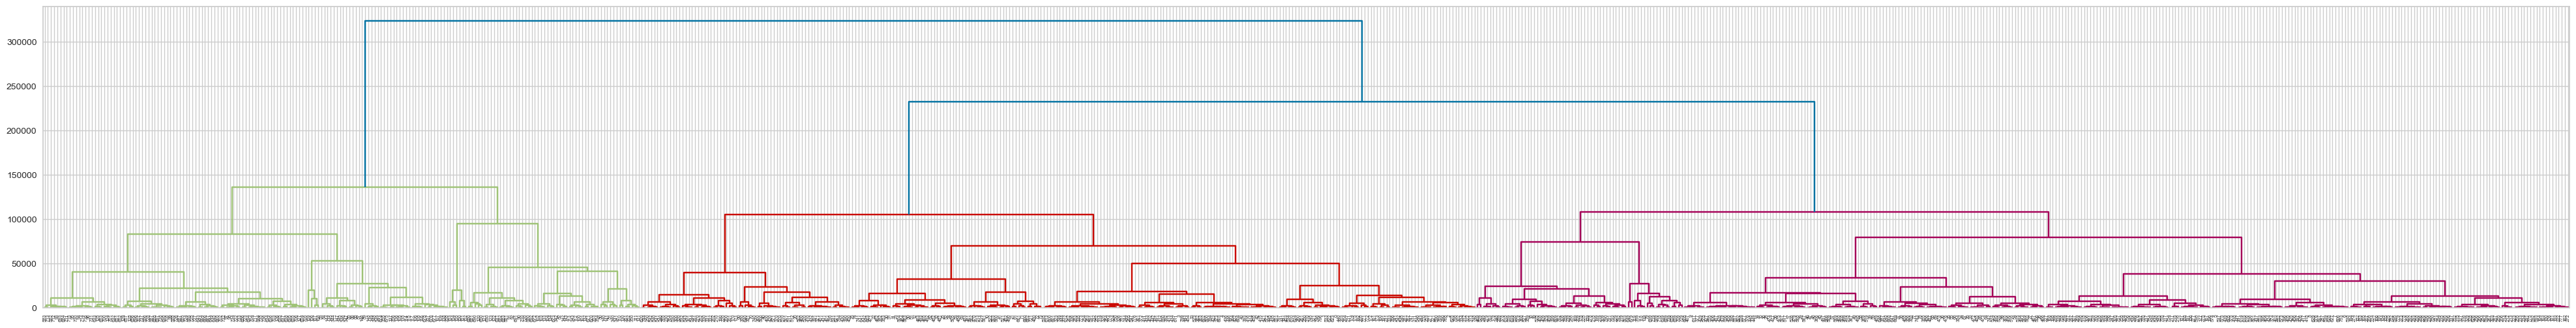

In [25]:
plt.figure(figsize=(50,6))
dendrogram(data);

In [26]:
from sklearn.cluster import DBSCAN

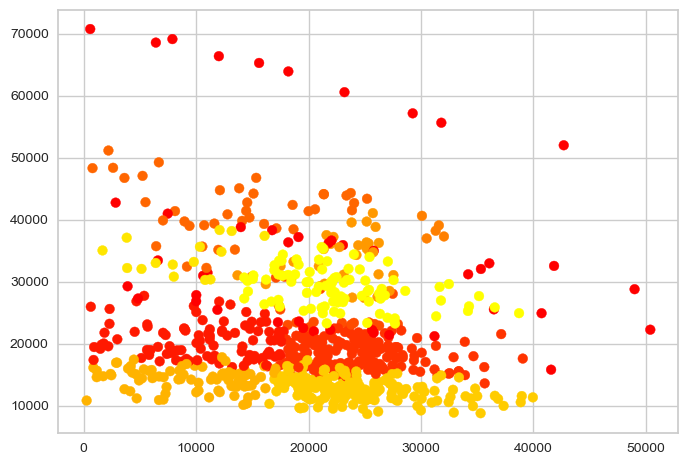

In [27]:
db=DBSCAN(min_samples=5)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(x)
y=db.fit_predict(x2)

plt.scatter(x['Mileage'],x['Price'],c=y,cmap='autumn');
plt.savefig('clustering.png', dpi=300)

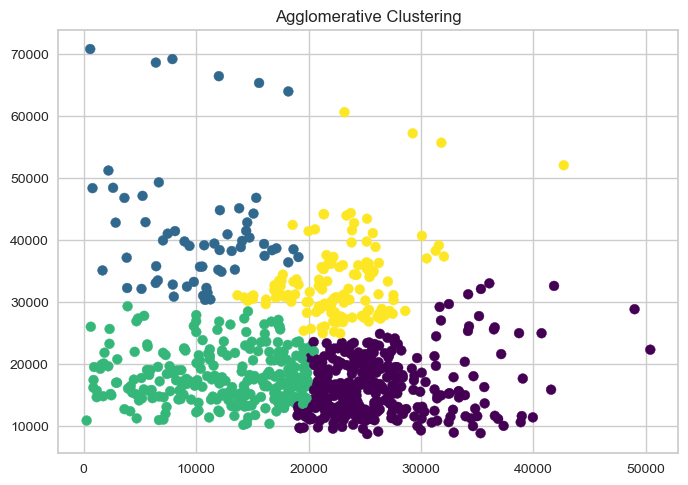

In [28]:
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(x)

# Plot the results
plt.scatter(x.Mileage, x.Price, c=y_agg, s=50, cmap='viridis')
plt.title("Agglomerative Clustering")
plt.show()

In [29]:
df=pd.read_csv('Billionaires.csv')

In [30]:
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


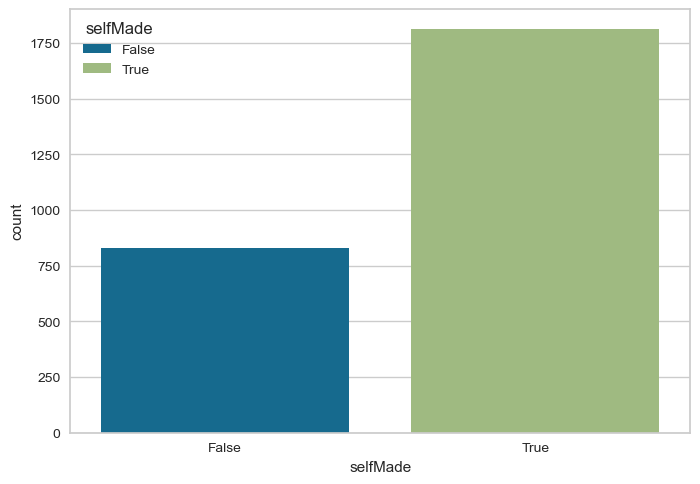

In [31]:
sns.countplot(x=df['selfMade'],hue=df['selfMade']);

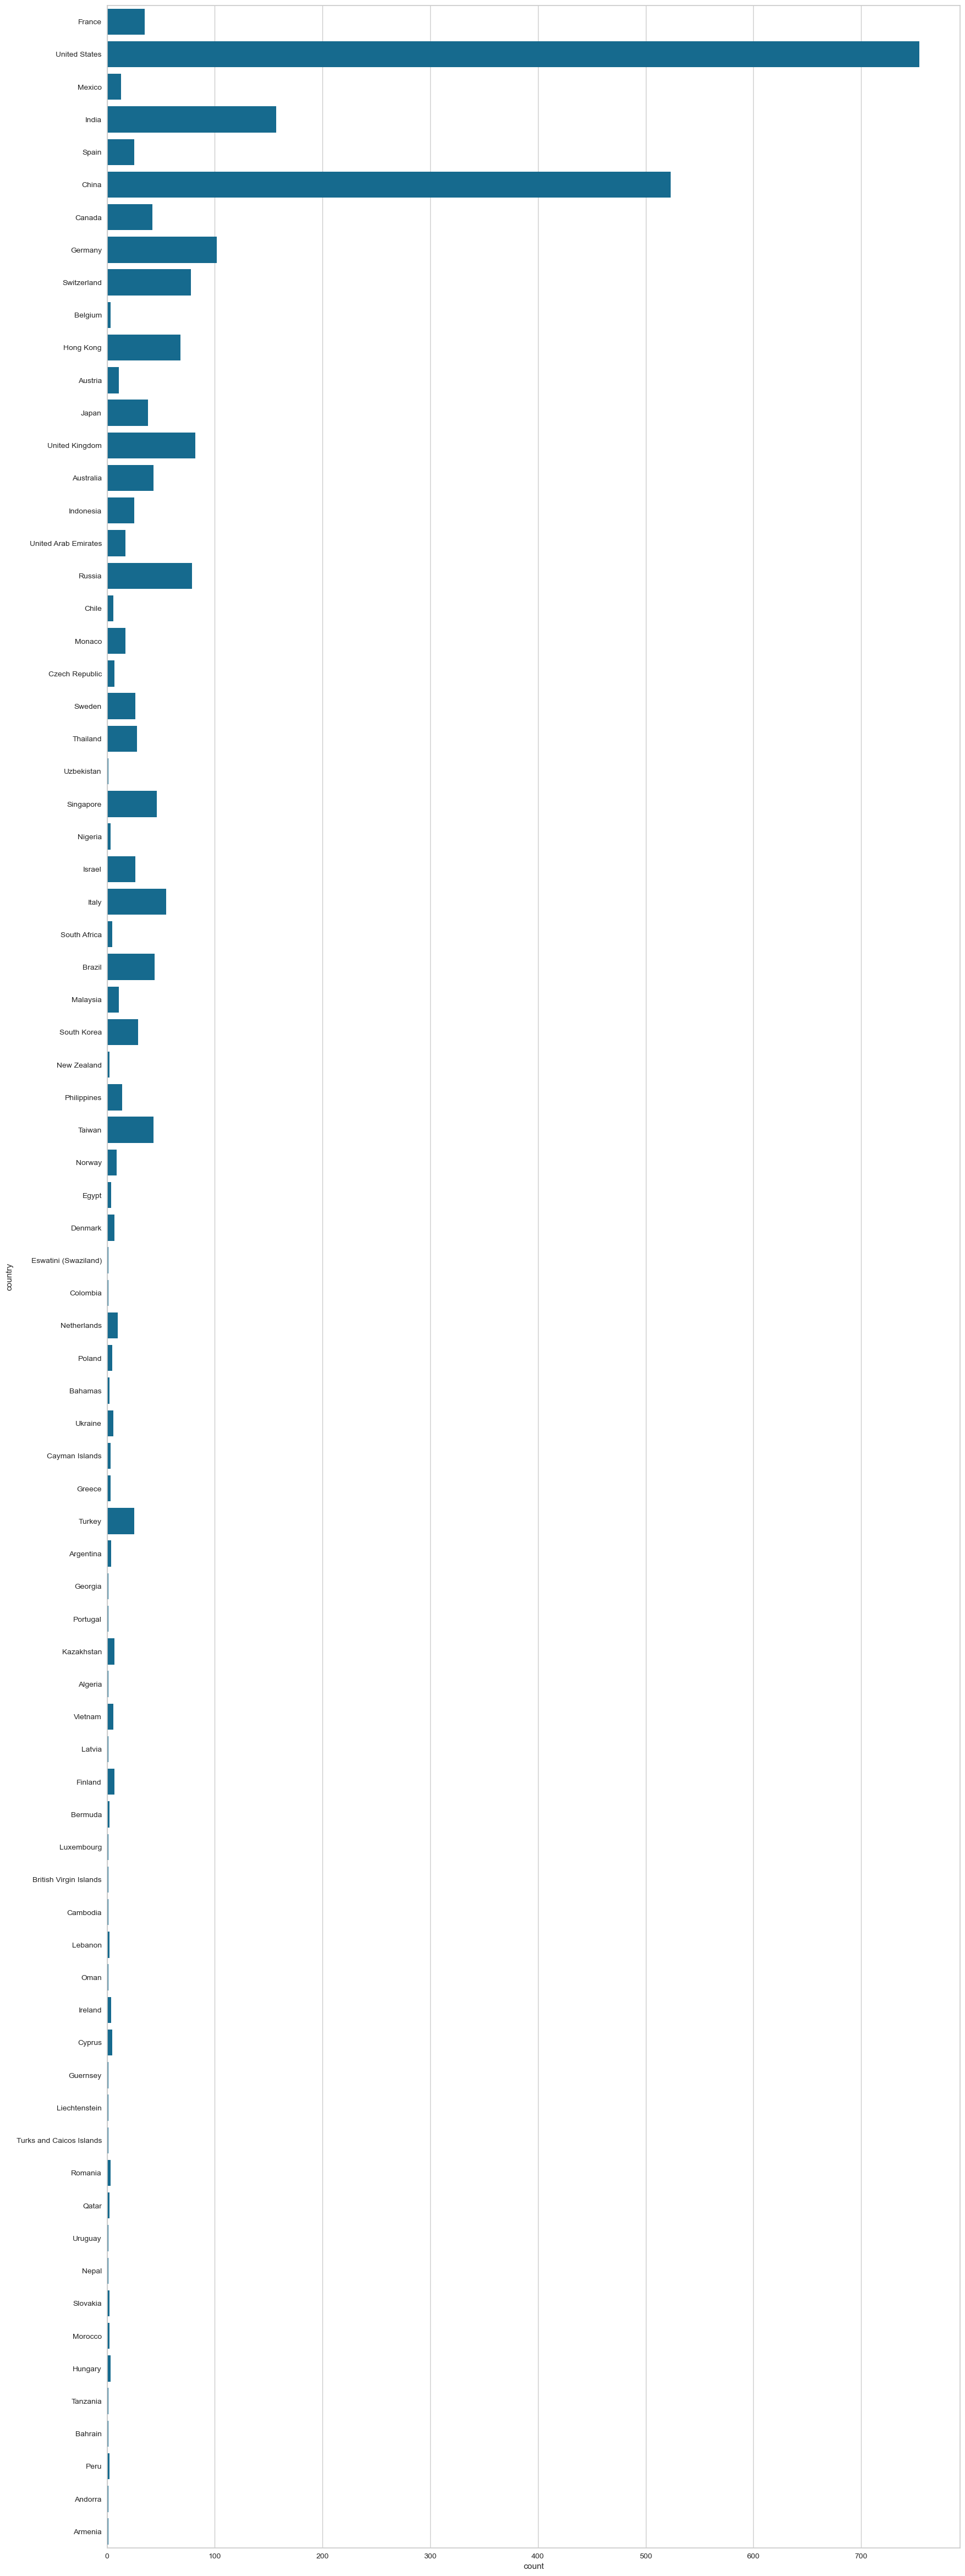

In [32]:
plt.figure(figsize=(20,60))
sns.countplot(y=df['country']);

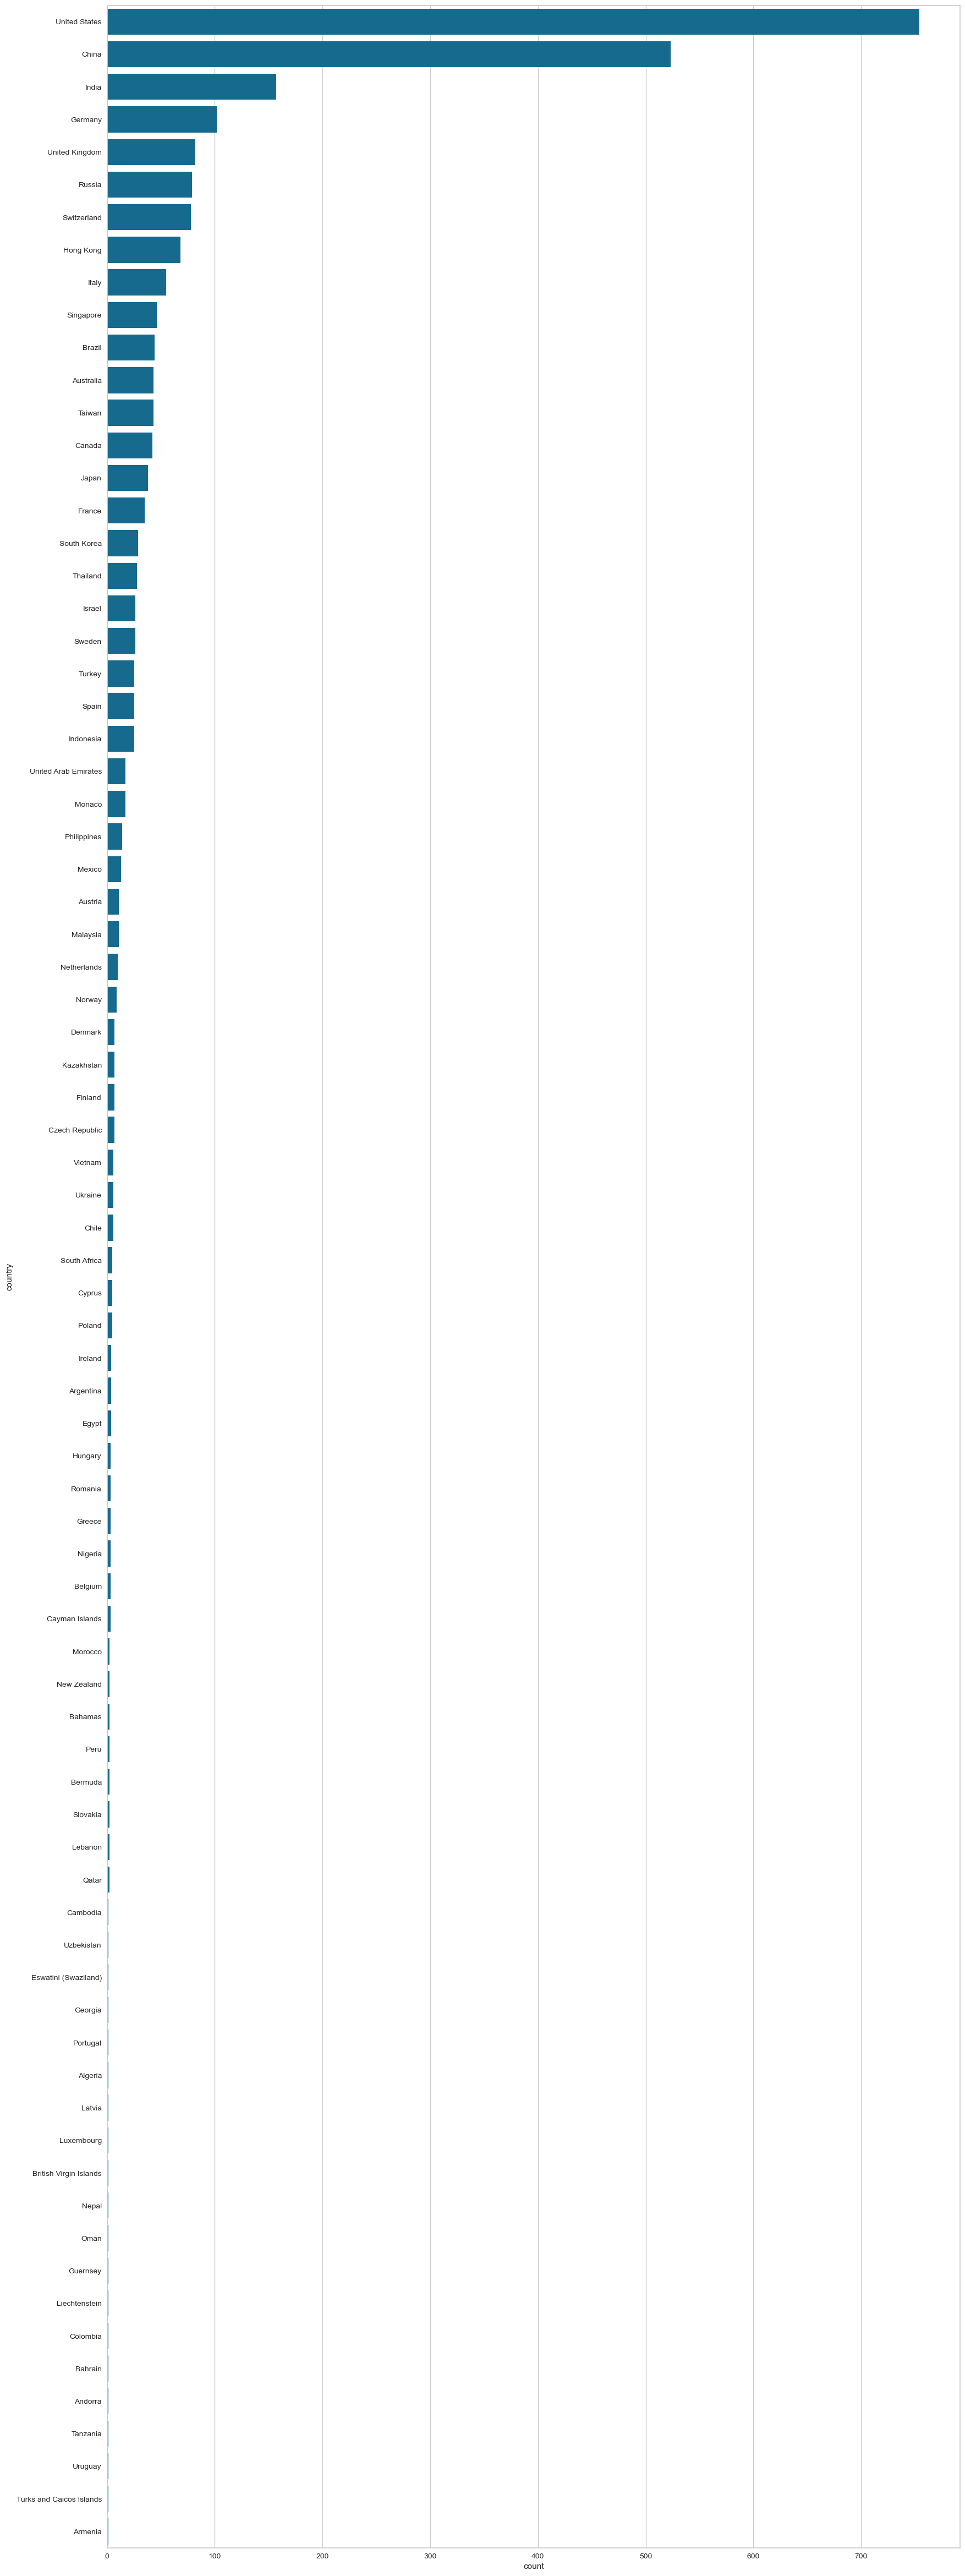

In [33]:
ydf=df['country'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(20,60))
sns.countplot(y=df['country'],order=ydf.index);

In [34]:
tr=df[df['country']=='Turkey']

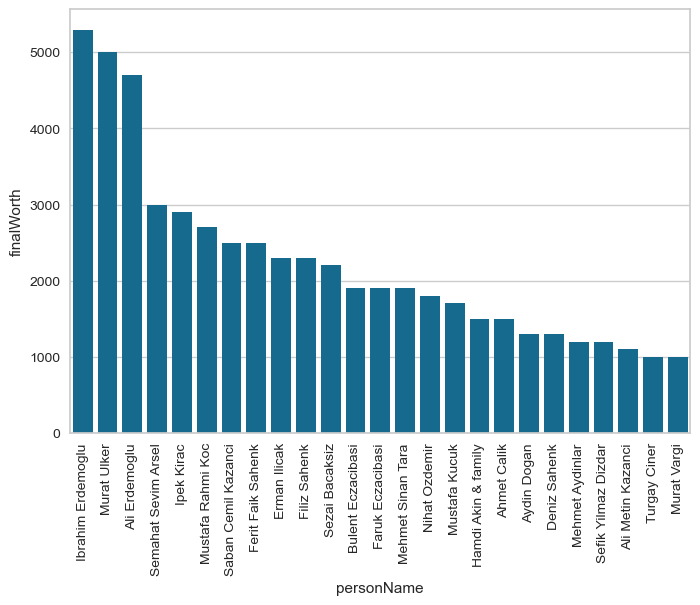

In [35]:
sns.barplot(x=tr['personName'],y=tr['finalWorth'])
plt.xticks(rotation=90);

<Axes: xlabel='selfMade', ylabel='count'>

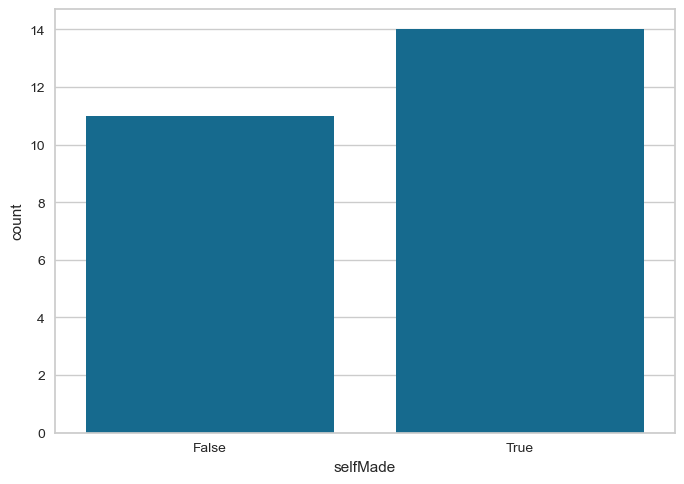

In [36]:
sns.countplot(x=tr['selfMade'])


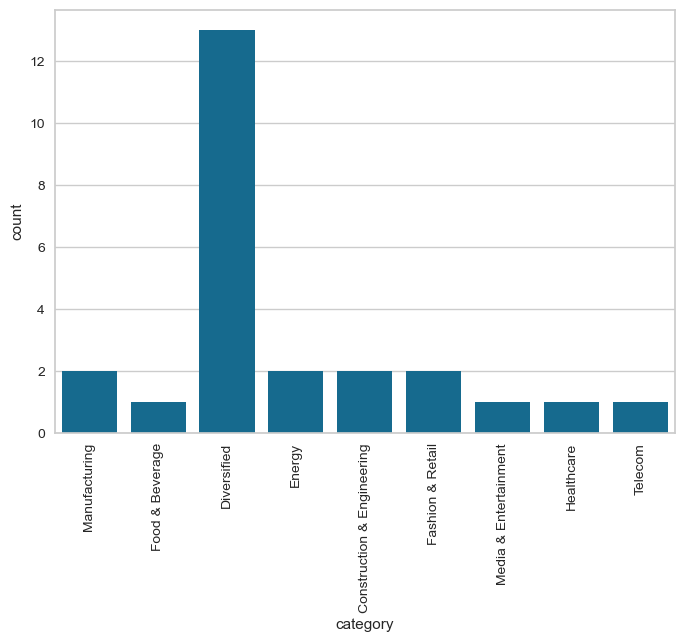

In [37]:
sns.countplot(x=tr['category'])
plt.xticks(rotation=90)
plt.show()

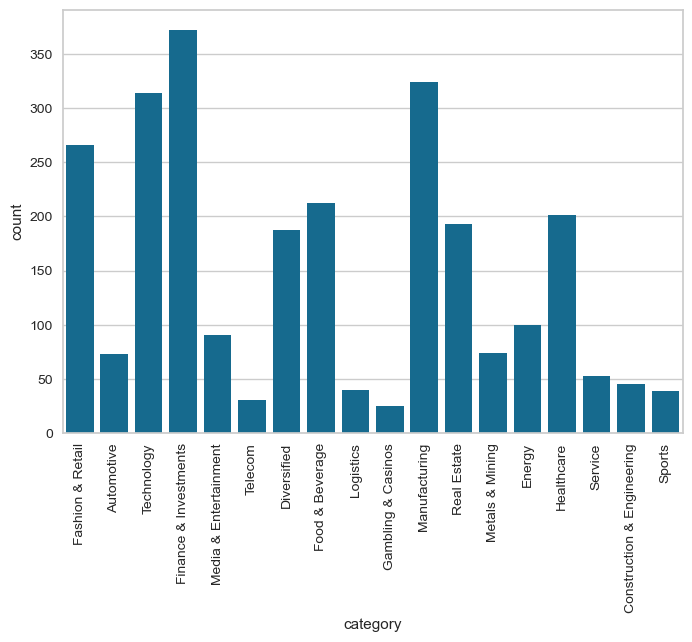

In [38]:
sns.countplot(x=df['category'])
plt.xticks(rotation=90)
plt.show()

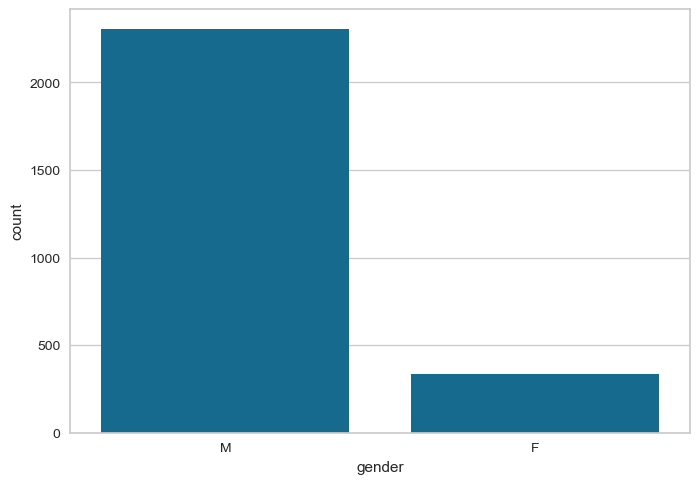

In [39]:
sns.countplot(x=df['gender']);

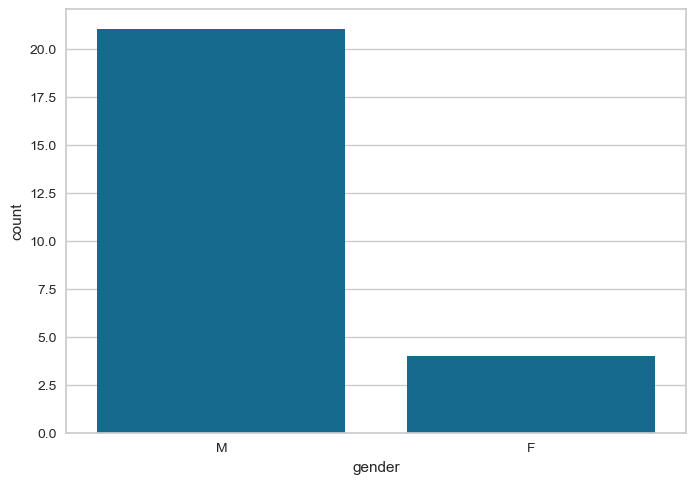

In [40]:
sns.countplot(x=tr['gender']);